In [18]:
##imports 

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [5]:
##load data

df = pd.read_csv('/Users/nic/Documents/MM2/data/ftc_enriched.csv')
print(df.shape)
df.head()

(339, 15)


,case_name,url,date,case_type,matter_number,case_status,summary,tags,long_title,statutes,penalty_usd,press_release_urls,pdf_urls,press_release_text,penalty_usd_enriched
0,"Amazon.com, Inc., U.S. v.",https://www.ftc.gov/legal-library/browse/cases...,2026-06-30,Federal,2523024,Pending,Amazon will pay $2.25 million in civil penalti...,Consumer Protection; Bureau of Consumer Protec...,"UNITED STATES OF AMERICA, Plaintiff v. AMAZON....",FCRA,2250000.0,https://www.ftc.gov/news-events/news/press-rel...,https://www.ftc.gov/system/files/ftc_gov/pdf/A...,Amazon will pay $2.25 million in civil penalti...,2250000.0
1,"FTC v Kochava, Inc.",https://www.ftc.gov/legal-library/browse/cases...,2026-06-26,Federal,NaN,Pending,The FTC will prohibit data broker Kochava and ...,Consumer Protection; Bureau of Consumer Protec...,"Federal Trade Commission, Plaintiff, V. Kochav...",NaN,NaN,https://www.ftc.gov/news-events/news/press-rel...,https://www.ftc.gov/system/files/ftc_gov/pdf/1...,The Federal Trade Commission filed a lawsuit a...,NaN
2,"Illuminate Education, Inc., In the Matter of",https://www.ftc.gov/legal-library/browse/cases...,2026-06-05,Administrative,2223105,Under Order,The Federal Trade Commission will require educ...,Consumer Protection; Bureau of Consumer Protec...,"In the Matter of ILLUMINATE EDUCATION, INC., a...",NaN,NaN,https://www.ftc.gov/news-events/news/press-rel...,https://www.ftc.gov/system/files/ftc_gov/pdf/2...,The Federal Trade Commission will require educ...,NaN
3,"Twitter, Inc., a corporation",https://www.ftc.gov/legal-library/browse/cases...,2026-06-03,Administrative,0923093,NaN,NaN,Consumer Protection; Bureau of Consumer Protec...,"In the Matter of Twitter, Inc.,a corporation",NaN,NaN,https://www.ftc.gov/news-events/news/press-rel...,https://www.ftc.gov/sites/default/files/docume...,Social networking service Twitter has agreed t...,NaN
4,"CMG Media Corporation, In the Matter of",https://www.ftc.gov/legal-library/browse/cases...,2026-05-21,Administrative,2423029,Pending,"The FTC will require Cox Media Group, MindSift...",Consumer Protection; Bureau of Consumer Protec...,In the Matter of CMG Media Corporation,NaN,930000.0,https://www.ftc.gov/news-events/news/press-rel...,https://www.ftc.gov/system/files/ftc_gov/pdf/C...,The Federal Trade Commission will require Cox ...,930000.0


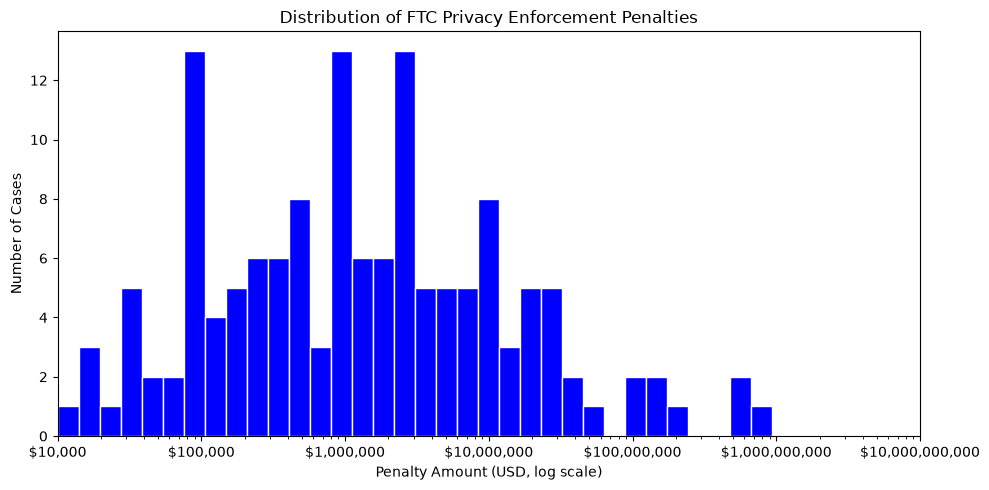

In [14]:
penalties = df['penalty_usd_enriched'].dropna()

fig, ax = plt.subplots(figsize=(10,5))
ax.hist(penalties, bins=np.logspace(np.log10(penalties.min()), np.log10(penalties.max()), 40), log=False, color='blue', edgecolor='white')
ax.set_xscale('log')
ax.set_xlabel('Penalty Amount (USD, log scale)')
ax.set_ylabel('Number of Cases')
ax.set_title('Distribution of FTC Privacy Enforcement Penalties')
ax.set_xlim(1e4, 1e10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

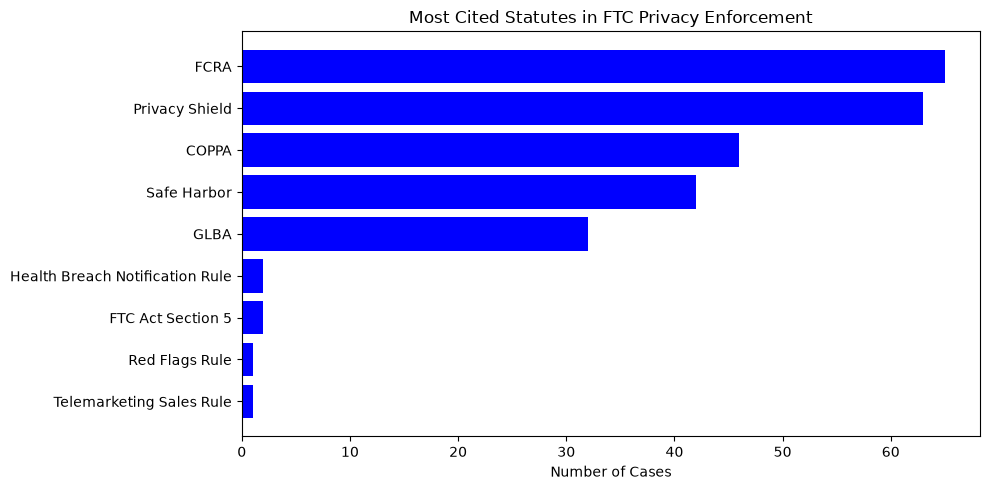

In [12]:
statutes = df['statutes'].dropna().str.split(';').explode().str.strip()

statute_counts = statutes.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(statute_counts.index[::-1], statute_counts.values[::-1], color='blue')
ax.set_xlabel('Number of Cases')
ax.set_title('Most Cited Statutes in FTC Privacy Enforcement')
plt.tight_layout()
plt.show()

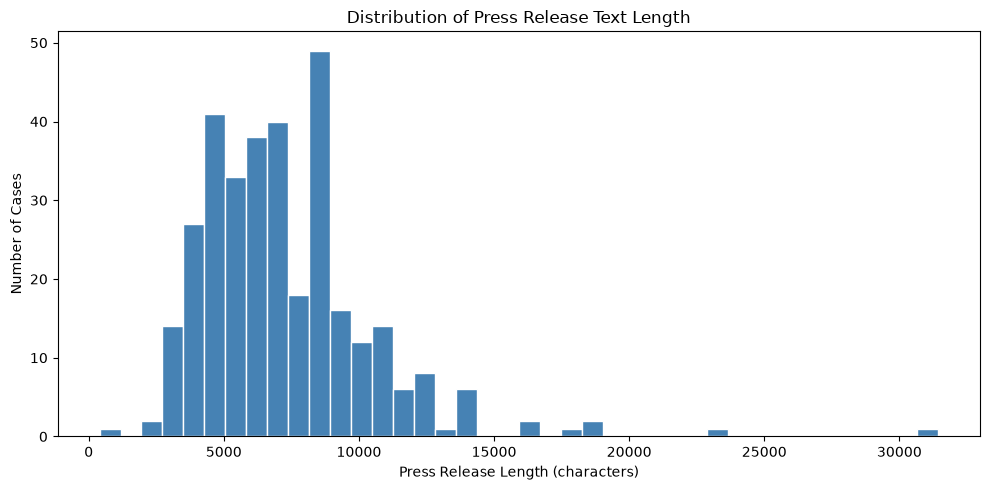

In [13]:
df['text_len'] = df['press_release_text'].dropna().apply(len)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['text_len'].dropna(), bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Press Release Length (characters)')
ax.set_ylabel('Number of Cases')
ax.set_title('Distribution of Press Release Text Length')
plt.tight_layout()
plt.show()

In [19]:
log_penalties = np.log10(df['penalty_usd_enriched'].dropna()).values.reshape(-1, 1)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(log_penalties)
centers = sorted(10 ** kmeans.cluster_centers_.flatten())
print('Cluster centers:', centers)

Cluster centers: [np.float64(129624.93503044728), np.float64(3982791.1993307513), np.float64(445945127.22899723)]


In [20]:
bins = [0, 1e6, 1e7, float('inf')]
labels = ['Low', 'Medium', 'High']
df['severity_tier'] = pd.cut(df['penalty_usd_enriched'], bins=bins, labels=labels)
print(df['severity_tier'].value_counts())

severity_tier
Low       71
Medium    49
High      27
Name: count, dtype: int64


In [21]:
all_tags = df['tags'].str.split(';').explode().str.strip().unique()
for tag in sorted(all_tags):
    print(tag)

Advertising and Marketing
Advertising and Marketing Basics
Alcohol
Artificial Intelligence
Automobiles
Big Data
Bureau of Consumer Protection
Cars
Children
Children's Online Privacy Protection Act (COPPA)
Children's Privacy
Clothing and Textiles
Consumer Privacy
Consumer Protection
Credit & Loan Offers
Credit Reporting
Credit and Finance
Credit and Loans
Data Privacy Framework
Data Security
Debt
Debt Collection
Debt Relief
Do Not Call
Education
Endorsements, Influencers, and Reviews
Entertainment
Fair Credit Reporting Act (FCRA)
Fake Check
FinTech
Finance
Franchises, Business Opportunities, and Investments
Gaming
Gramm-Leach-Bliley Act
Health
Health Care
Health Claims
Health Privacy
Health Professional Services
Human Resources
Identity Theft
Internet of Things
Merchandise & Clothing
Mobile
Mortgages
Northwest Region
Office of Technology Research and Investigation (OTech)
Office of the General Counsel
Online Advertising and Marketing
Over-the-Counter Drugs and Devices
Payments and Billi

In [22]:
statute_tag = df[['statutes', 'tags']].dropna()
combos = set()
for _, row in statute_tag.iterrows():
    statutes = [s.strip() for s in row['statutes'].split(';')]
    tags = [t.strip() for t in row['tags'].split(';')]
    for statute in statutes:
        for tag in tags:
            combos.add((statute, tag))

for combo in sorted(combos):
    print(f"{combo[0]} - {combo[1]}")

COPPA - Advertising and Marketing
COPPA - Advertising and Marketing Basics
COPPA - Artificial Intelligence
COPPA - Bureau of Consumer Protection
COPPA - Children
COPPA - Children's Online Privacy Protection Act (COPPA)
COPPA - Children's Privacy
COPPA - Consumer Privacy
COPPA - Consumer Protection
COPPA - Data Security
COPPA - Entertainment
COPPA - Gaming
COPPA - Mobile
COPPA - Office of Technology Research and Investigation (OTech)
COPPA - Online Advertising and Marketing
COPPA - Privacy and Security
COPPA - Regional Offices
COPPA - Retail
COPPA - Social Media
COPPA - Software and Databases
COPPA - Tech
COPPA - Technology
COPPA - Weight Loss
COPPA - Western Region
COPPA - Western Region Los Angeles
COPPA - Western Region San Francisco
COPPA - deceptive/misleading conduct
FCRA - Advertising and Marketing
FCRA - Automobiles
FCRA - Bureau of Consumer Protection
FCRA - Consumer Privacy
FCRA - Consumer Protection
FCRA - Credit & Loan Offers
FCRA - Credit Reporting
FCRA - Credit and Finance

In [23]:
no_statute = df[df['statutes'].isna()]
print(len(no_statute))
print(no_statute['press_release_text'].notna().sum())

138
134


In [24]:
import re

statute_patterns = {
    'COPPA': r'COPPA|Children\'s Online Privacy Protection',
    'GLBA': r'GLBA|Gramm.Leach.Bliley',
    'FCRA': r'FCRA|Fair Credit Reporting',
    'FTC Act Section 5': r'Section 5|FTC Act|15 U\.S\.C\.?\s*§?\s*45',
    'HIPAA': r'HIPAA|Health Insurance Portability',
    'CAN-SPAM': r'CAN.SPAM',
    'TSR': r'Telemarketing Sales Rule|TSR',
    'HBNR': r'Health Breach Notification',
    'Privacy Shield': r'Privacy Shield',
    'Safe Harbor': r'Safe Harbor',
    'FCRA': r'Fair Credit Reporting Act|FCRA',
    'Red Flags Rule': r'Red Flags Rule',
}

def extract_statutes_from_text(text):
    if pd.isna(text):
        return None
    found = []
    for name, pattern in statute_patterns.items():
        if re.search(pattern, text, re.IGNORECASE):
            found.append(name)
    return ';'.join(found) if found else None

df['statutes_recovered'] = df.apply(
    lambda row: row['statutes'] if pd.notna(row['statutes'])
    else extract_statutes_from_text(row['press_release_text']),
    axis=1
)

print(df['statutes_recovered'].notna().sum())

279


In [27]:
still_missing = df[df['statutes_recovered'].isna()]
print(still_missing[['case_name', 'tags']].to_string())

                                                                                                                   case_name                                                                                                                                                                                     tags
2                                                                               Illuminate Education, Inc., In the Matter of                                                                              Consumer Protection; Bureau of Consumer Protection; Privacy and Security; Children's Privacy; Data Security
3                                                                                               Twitter, Inc., a corporation                                                            Consumer Protection; Bureau of Consumer Protection; Privacy and Security; Consumer Privacy; Data Security; Tech; Social Media
5                                                                     

In [28]:
def fallback_section5(row):
    if pd.notna(row['statutes_recovered']):
        return row['statutes_recovered']
    if pd.notna(row['tags']) and 'Privacy and Security' in row['tags']:
        return 'FTC Act Section 5'
    return None

df['statutes_final'] = df.apply(fallback_section5, axis=1)
print(df['statutes_final'].notna().sum())
print(df['statutes_final'].value_counts())

336
statutes_final
FTC Act Section 5                        109
FCRA                                      56
COPPA                                     48
Privacy Shield; Safe Harbor               41
GLBA                                      25
Privacy Shield                            23
GLBA; FCRA                                 7
HIPAA                                      4
HBNR                                       2
FTC Act Section 5;HIPAA                    2
Health Breach Notification Rule            2
COPPA;FTC Act Section 5                    2
FTC Act Section 5;Privacy Shield           2
FTC Act Section 5;Safe Harbor              2
GLBA;FTC Act Section 5                     2
FCRA; Red Flags Rule                       1
HIPAA;CAN-SPAM;Privacy Shield              1
FTC Act Section 5; Privacy Shield          1
FCRA;FTC Act Section 5                     1
FTC Act Section 5; COPPA; Safe Harbor      1
FCRA; Telemarketing Sales Rule             1
COPPA;Safe Harbor                   

In [29]:
def parse_labels(statute_str):
    if pd.isna(statute_str):
        return []
    parts = re.split(r'[;,]', statute_str)
    return [p.strip() for p in parts if p.strip()]

df['violation_labels'] = df['statutes_final'].apply(parse_labels)

# check it
print(df['violation_labels'].head(10).tolist())
print()
print('Cases with at least one label:', df['violation_labels'].apply(len).gt(0).sum())
print('Cases with multiple labels:', df['violation_labels'].apply(len).gt(1).sum())

[['FCRA'], ['HBNR'], ['FTC Act Section 5'], ['FTC Act Section 5'], ['FTC Act Section 5'], ['FTC Act Section 5'], ['FTC Act Section 5'], ['COPPA'], ['COPPA'], ['FTC Act Section 5']]

Cases with at least one label: 336
Cases with multiple labels: 67


In [30]:
label_map = {
    'Health Breach Notification Rule': 'HBNR',
    'Safe Harbor': 'Privacy Shield',
    'FTC Act Section 5': 'Section 5',
    'Telemarketing Sales Rule': 'TSR',
    'Red Flags Rule': 'FCRA',
}

def normalize_labels(label_list):
    return list(set(label_map.get(l, l) for l in label_list))

df['violation_labels'] = df['violation_labels'].apply(normalize_labels)
print(df['violation_labels'].explode().value_counts())

violation_labels
Section 5         124
Privacy Shield     72
FCRA               66
COPPA              52
GLBA               34
HIPAA               7
HBNR                4
CAN-SPAM            2
TSR                 2
Name: count, dtype: int64


In [32]:
major_labels = {'Section 5', 'Privacy Shield', 'FCRA', 'COPPA', 'GLBA'}

def consolidate_labels(label_list):
    return [l if l in major_labels else 'Other' for l in label_list]

df['violation_labels'] = df['violation_labels'].apply(consolidate_labels)
print(df['violation_labels'].explode().value_counts())

violation_labels
Section 5         124
Privacy Shield     72
FCRA               66
COPPA              52
GLBA               34
Other              15
Name: count, dtype: int64


In [33]:
df.to_csv('/Users/nic/Documents/MM2/data/ftc_labeled.csv', index=False)


In [36]:
tag = 'Debt'  # replace with whatever tag you're evaluating
matches = df[df['tags'].str.contains(tag, na=False)][['case_name', 'tags', 'press_release_text']].head(3)
for _, row in matches.iterrows():
    print(row['case_name'])
    print(row['tags'])
    print(str(row['press_release_text'])[:300])
    print('---')

ITMedia Solutions LLC
Consumer Protection; Office of the General Counsel; Bureau of Consumer Protection; Credit & Loan Offers; Debt Relief; deceptive/misleading conduct; Credit and Finance; Credit and Loans; Privacy and Security; Consumer Privacy
A lead generation company that collected sensitive information from millions of consumers under the guise of connecting them with lenders will pay $1.5 million in civil penalties and face restrictions on their operations as a result of a Federal Trade Commission lawsuit. The FTC’s complaint alleges 
---
Midwest Recovery Systems, LLC
Consumer Protection; Credit and Finance; Debt Collection; Privacy and Security; Credit Reporting
The Federal Trade Commission has taken action against a debt collection company that allegedly placed bogus or highly questionable debts onto consumers’ credit reports to coerce them to pay the debts. Under a settlement with the FTC, the company, Midwest Recovery Systems (Midwest Recovery), is prohi
---
BoostMyScore LLC